In [1]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.data_loader import MPDDataLoader

loader = MPDDataLoader(data_folder='../data/')
playlists = loader.load_playlists(max_files=50)  # adjust for testing
track_df = loader.build_track_df(playlists)

track_df.head()


,pid,track_uri,track_name,artist_uri,artist_name,album_uri,album_name
0,115000,spotify:track:0ESJlaM8CE1jRWaNtwSNj8,beibs in the trap,spotify:artist:0Y5tJX1MQlPlqiwlOH1tJY,Travis Scott,spotify:album:42WVQWuf1teDysXiOupIZt,Birds In The Trap Sing McKnight
1,115000,spotify:track:6gBFPUFcJLzWGx4lenP6h2,goosebumps,spotify:artist:0Y5tJX1MQlPlqiwlOH1tJY,Travis Scott,spotify:album:42WVQWuf1teDysXiOupIZt,Birds In The Trap Sing McKnight
2,115000,spotify:track:2c2csx4OTYtbkzvbSTXlGY,guidance,spotify:artist:0Y5tJX1MQlPlqiwlOH1tJY,Travis Scott,spotify:album:42WVQWuf1teDysXiOupIZt,Birds In The Trap Sing McKnight
3,115000,spotify:track:1yxgsra98r3qAtxqiGZPiX,Butterfly Effect,spotify:artist:0Y5tJX1MQlPlqiwlOH1tJY,Travis Scott,spotify:album:4fOw7xSDwqb58Z2Qia5j81,Butterfly Effect
4,115000,spotify:track:1SGt65i9AnXYdDQt1AtDRH,3500,spotify:artist:0Y5tJX1MQlPlqiwlOH1tJY,Travis Scott,spotify:album:4PWBTB6NYSKQwfo79I3prg,Rodeo


In [2]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
   sys.path.append(project_root) 
from src.spotify_api import SpotifyAPI

CLIENT_ID = "8d0b81b7efd94d28be4b8e5cfd9bbad5"
CLIENT_SECRET = "a26d760401044cb6bf19a0c03e444b89"
api = SpotifyAPI(CLIENT_ID, CLIENT_SECRET)
info = api.get_track_info('spotify:track:6JsZyX0Emuzy7swG21tgt7')
print(info)



{'album': {'album_type': 'compilation', 'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/7N3JfLDzzjXdPbsyco7X0l'}, 'href': 'https://api.spotify.com/v1/artists/7N3JfLDzzjXdPbsyco7X0l', 'id': '7N3JfLDzzjXdPbsyco7X0l', 'name': 'The String Cheese Incident', 'type': 'artist', 'uri': 'spotify:artist:7N3JfLDzzjXdPbsyco7X0l'}], 'available_markets': ['AR', 'AU', 'AT', 'BE', 'BO', 'BR', 'BG', 'CA', 'CL', 'CO', 'CR', 'CY', 'CZ', 'DK', 'DO', 'DE', 'EC', 'EE', 'SV', 'FI', 'FR', 'GR', 'GT', 'HN', 'HK', 'HU', 'IS', 'IE', 'IT', 'LV', 'LT', 'LU', 'MY', 'MT', 'MX', 'NL', 'NZ', 'NI', 'NO', 'PA', 'PY', 'PE', 'PH', 'PL', 'PT', 'SG', 'SK', 'ES', 'SE', 'CH', 'TW', 'TR', 'UY', 'US', 'GB', 'AD', 'LI', 'MC', 'ID', 'JP', 'TH', 'VN', 'RO', 'IL', 'ZA', 'SA', 'AE', 'BH', 'QA', 'OM', 'KW', 'EG', 'MA', 'DZ', 'TN', 'LB', 'JO', 'PS', 'IN', 'BY', 'KZ', 'MD', 'UA', 'AL', 'BA', 'HR', 'ME', 'MK', 'RS', 'SI', 'KR', 'BD', 'PK', 'LK', 'GH', 'KE', 'NG', 'TZ', 'UG', 'AG', 'AM', 'BS', 'BB', 'BZ', 'BT', 

In [3]:
track_uris = track_df['track_uri'].unique().tolist()

In [4]:
features = api.get_multiple_audio_features(track_uris[:10])
print(features)


Fetching audio features:   0%|          | 0/1 [00:00<?, ?it/s]
ERROR:src.spotify_api:Unexpected error: http status: 403, code: -1 - https://api.spotify.com/v1/audio-features/?ids=0ESJlaM8CE1jRWaNtwSNj8,6gBFPUFcJLzWGx4lenP6h2,2c2csx4OTYtbkzvbSTXlGY,1yxgsra98r3qAtxqiGZPiX,1SGt65i9AnXYdDQt1AtDRH,51EC3I1nQXpec4gDk0mQyP,3xby7fOyqmeON8jsnom0AT,1wHZx0LgzFHyeIZkUydNXq,3Ytr1SUCUi6J3L9dRFx5iH,20dP2DaMHIAmwWAbp7peSr:
 None, reason: None


None


In [6]:
# Skip audio features fetching for now due to 403 errors
# audio_features_list = spotify_api.get_audio_features_sequential(track_ids)
# audio_features_df = pd.DataFrame(audio_features_list)

# Instead, create an empty dataframe or fill with NaNs to keep pipeline working
import numpy as np
import pandas as pd

audio_features_df = pd.DataFrame(columns=[
    'id', 'danceability', 'energy', 'valence', 'tempo', # add other audio features you expect
])

# Add track_id column to merge
audio_features_df['track_id'] = []

# Prepare your track_df for merging
track_df['track_id'] = track_df['track_uri'].apply(lambda x: x.split(':')[-1])

# Merge (will keep audio feature columns empty)
track_enriched_df = pd.merge(track_df, audio_features_df, on='track_id', how='left')

# Continue with your next steps...


In [ ]:
from embedding_model import EmbeddingGenerator

embedder = EmbeddingGenerator()

# Get track popularity mapping (this is fine)
popularity = embedder.track_popularity(track_df)

# Build playlists list: one row per playlist
playlists_df = (
    track_df.groupby('pid').first().reset_index()
)

# Add dummy name
playlists_df['name'] = 'my playlist'

# Convert to list of dicts
playlists = playlists_df.to_dict(orient='records')

# Create embeddings
playlist_embeddings = embedder.playlist_title_embeddings(playlists)

print(f"Playlist title embeddings shape: {playlist_embeddings.shape}")
print(f"Number of unique tracks: {len(popularity)}")


Playlist title embeddings shape: (50000, 2)
Number of unique tracks: 462106


In [11]:
from src.cf_model import CFRecommender

cf = CFRecommender()
cf.train(track_df)




# Get unique playlist row indices
unique_playlist_indices = cf.playlist_codes.unique()
# playlist_idx = unique_playlist_indices[0]
# Pick first playlist category ID
first_pid = cf.playlist_categories[0]

# Map that ID to the integer code (row index)
playlist_idx = list(cf.playlist_mapping.keys())[list(cf.playlist_mapping.values()).index(first_pid)]

print(f"Using playlist idx {playlist_idx} for playlist id {first_pid}")


print(f"user_item_matrix shape: {cf.user_item_matrix.shape}")
print(f"playlist_idx: {playlist_idx}")

cf_scores = dict(cf.recommend_for_playlist(playlist_idx, N=20))

print("Top 20 CF recommendations:")
for track_uri, score in list(cf_scores.items())[:5]:
    print(f"{track_uri}: {score:.3f}")



/opt/anaconda3/lib/python3.12/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/10 [00:00<?, ?it/s]

Using playlist idx 0 for playlist id 3000
user_item_matrix shape: (50000, 462106)
playlist_idx: 0
Top 20 CF recommendations:
spotify:track:7BKLCZ1jbUBVqRi2FVlTVw: 0.002
spotify:track:04DwTuZ2VBdJCCC5TROn7L: 0.002
spotify:track:4pdPtRcBmOSQDlJ3Fk945m: 0.002
spotify:track:46lFttIf5hnUZMGvjK0Wxo: 0.002
spotify:track:6YUTL4dYpB9xZO5qExPf05: 0.002


In [8]:
print(audio_features_df.columns.tolist())


['id', 'danceability', 'energy', 'valence', 'tempo', 'track_id']


In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from src.content_model import ContentRecommender

# Assume audio_features_df has audio features for tracks with 'id' as track id
# and track_df has 'pid' (playlist id) and 'track_uri' columns

# Merge audio features with track_df
audio_features_df['track_id'] = audio_features_df['id']
track_df['track_id'] = track_df['track_uri'].apply(lambda x: x.split(':')[-1])
merged_df = pd.merge(track_df, audio_features_df, on='track_id', how='left')

# Select relevant audio features (make sure these columns exist in audio_features_df)
feature_cols = ['danceability', 'energy', 'valence', 'tempo']
features = merged_df[feature_cols].fillna(0)

# Normalize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Add scaled features back to merged_df
for i, col in enumerate(feature_cols):
    merged_df[col + '_scaled'] = features_scaled[:, i]

# Calculate playlist embeddings as average of track embeddings in that playlist
playlist_embeddings_df = (
    merged_df.groupby('pid')[[col + '_scaled' for col in feature_cols]].mean()
)

# Convert to numpy array (playlists x embedding_dim)
playlist_embeddings = playlist_embeddings_df.values

# Create track embeddings (scaled audio features)
track_embeddings = features_scaled

# Create track URIs list in same order as track_embeddings
track_uris = merged_df['track_uri'].tolist()

# Now, playlist_embeddings and track_embeddings have the same dimension (4 features)

# Example ContentRecommender usage
content = ContentRecommender(playlist_embeddings, track_embeddings, track_uris)

playlist_idx = 0  # for example, first playlist

content_scores = dict(content.recommend_for_playlist(playlist_idx, N=20))

print("Top 20 Content-Based recommendations:")
for track_uri, score in list(content_scores.items())[:5]:
    print(f"{track_uri}: {score:.3f}")


/var/folders/x3/xlf84vmx7xv6jybnkt035hzh0000gn/T/ipykernel_71171/3383875539.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features = merged_df[feature_cols].fillna(0)


Top 20 Content-Based recommendations:
spotify:track:6H0AwSQ20mo62jGlPGB8S6: 0.000
spotify:track:2p3ByN7qyhZD2nM8zSVsil: 0.000
spotify:track:5dUxIdq8o7HSBDYqIEXcNR: 0.000
spotify:track:5OM1p9cVPxzUxN0HfRYvWh: 0.000
spotify:track:7MSuEyj8woELvqNYNc6OtR: 0.000


In [14]:
from src.hybrid_model import HybridRecommender

# Initialize hybrid model
hybrid = HybridRecommender(cf_model=cf, content_model=content, alpha=0.7)

# Recommend for the same playlist_idx
hybrid_scores = dict(hybrid.recommend_for_playlist(playlist_idx, N=20))

print("Top 20 Hybrid recommendations:")
for track_uri, score in list(hybrid_scores.items())[:5]:
    print(f"{track_uri}: {score:.3f}")


Top 20 Hybrid recommendations:
spotify:track:7BKLCZ1jbUBVqRi2FVlTVw: 0.002
spotify:track:04DwTuZ2VBdJCCC5TROn7L: 0.001
spotify:track:4pdPtRcBmOSQDlJ3Fk945m: 0.001
spotify:track:46lFttIf5hnUZMGvjK0Wxo: 0.001
spotify:track:6YUTL4dYpB9xZO5qExPf05: 0.001


In [15]:
from src.reranker import FairnessReranker

# Initialize reranker with popularity dict
reranker = FairnessReranker(popularity, beta=0.5, epsilon=1e-6)

# Get hybrid recommendations (reuse previous)
hybrid_recs = hybrid.recommend_for_playlist(playlist_idx, N=50)

# Rerank for fairness and diversity
reranked_recs = reranker.rerank(hybrid_recs)

print("Top 20 Reranked recommendations:")
for track_uri, score in reranked_recs[:20]:
    print(f"{track_uri}: {score:.4f}")


Top 20 Reranked recommendations:
spotify:track:7BKLCZ1jbUBVqRi2FVlTVw: 0.0006
spotify:track:04DwTuZ2VBdJCCC5TROn7L: 0.0006
spotify:track:4pdPtRcBmOSQDlJ3Fk945m: 0.0006
spotify:track:46lFttIf5hnUZMGvjK0Wxo: 0.0006
spotify:track:6YUTL4dYpB9xZO5qExPf05: 0.0006
spotify:track:6DNtNfH8hXkqOX1sjqmI7p: 0.0005
spotify:track:4J7CKHCF3mdL4diUsmW8lq: 0.0005
spotify:track:4OZEu0Vwq0RB2LAq14v99n: 0.0005
spotify:track:6eIacmhkE82vZlMDnGS7aP: 0.0004
spotify:track:1I8tHoNBFTuoJAlh4hfVVE: 0.0004
spotify:track:2CAK2t1reUgPK6OMgAMURB: 0.0004
spotify:track:60wwxj6Dd9NJlirf84wr2c: 0.0004
spotify:track:7MmG8p0F9N3C4AXdK6o6Eb: 0.0004
spotify:track:66hayvUbTotekKU3H4ta1f: 0.0004
spotify:track:2rizacJSyD9S1IQUxUxnsK: 0.0004
spotify:track:07nH4ifBxUB4lZcsf44Brn: 0.0004
spotify:track:4WjH9Bzt3kx7z8kl0awxh4: 0.0004
spotify:track:6JEntXLt4z98CcDtIH9sU7: 0.0004
spotify:track:2QtJA4gbwe1AcanB2p21aP: 0.0004
spotify:track:015IsLQFXbEm0f541N2qoX: 0.0004


In [7]:
for track_uri, _ in reranked_recs[:5]:
    print(track_uri, popularity.get(track_uri, 'Not found'))


spotify:track:5NNSLOPIXs1rQE6hDNFS5e 1
spotify:track:3DFEMQEzEp2B7FSB6mTzv7 1
spotify:track:37lMlqtNFKVsNWRWoHMhFE 1
spotify:track:1cjXYzFXdHGppaMFFvU64g 1
spotify:track:1aV4jHoCq4ebDRo6CigANa 1


In [8]:
print(list(popularity.items())[:10])


[('spotify:track:00039MgrmLoIzSpuYKurn9', 2), ('spotify:track:0006Rv1e2Xfh6QooyKJqKS', 1), ('spotify:track:000DfZJww8KiixTKuk9usJ', 1), ('spotify:track:000HmzbYBg0Uxe6cE47Tws', 1), ('spotify:track:000ULyVqUhqnAyA0Um3MEH', 1), ('spotify:track:000VZqvXwT0YNqKk7iG2GS', 1), ('spotify:track:000WkK6rRXx9fRbrw3L7W8', 1), ('spotify:track:000cAxMxUfuDlvPYIVrrZ4', 1), ('spotify:track:000hWSuTFE8kVfaslBvgDP', 1), ('spotify:track:000vBQK1sQ1ppKAEUBmYuG', 1)]


In [16]:
import numpy as np

def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / k

def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / len(relevant) if relevant else 0

def dcg_at_k(recommended, relevant, k):
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1 / np.log2(i + 2)  # i starts at 0
    return dcg

def idcg_at_k(relevant, k):
    idcg = 0.0
    n = min(len(relevant), k)
    for i in range(n):
        idcg += 1 / np.log2(i + 2)
    return idcg

def ndcg_at_k(recommended, relevant, k):
    dcg = dcg_at_k(recommended, relevant, k)
    idcg = idcg_at_k(relevant, k)
    return dcg / idcg if idcg > 0 else 0


In [22]:
from sklearn.metrics import ndcg_score
import numpy as np

# Parameters
N = 20
K = 20  # Top-K for evaluation
playlist_indices = cf.playlist_codes.unique()[:10]  # use first 10 playlists for demo

cf_precisions, content_precisions, hybrid_precisions, reranked_precisions = [], [], [], []
cf_recalls, content_recalls, hybrid_recalls, reranked_recalls = [], [], [], []
cf_ndcgs, content_ndcgs, hybrid_ndcgs, reranked_ndcgs = [], [], [], []

for playlist_idx in playlist_indices:
    cf_recs = list(cf.recommend_for_playlist(playlist_idx, N))
    content_recs = list(content.recommend_for_playlist(playlist_idx, N))
    hybrid_recs = list(hybrid.recommend_for_playlist(playlist_idx, N))
    reranked_recs = reranker.rerank(hybrid_recs)[:K]
    
    # Extract track URIs and scores
    cf_uris = [t[0] for t in cf_recs]
    cf_scores = [t[1] for t in cf_recs]
    content_uris = [t[0] for t in content_recs]
    content_scores = [t[1] for t in content_recs]
    hybrid_uris = [t[0] for t in hybrid_recs]
    hybrid_scores = [t[1] for t in hybrid_recs]
    reranked_uris = [t[0] for t in reranked_recs]
    reranked_scores = [t[1] for t in reranked_recs]

    # Ground truth tracks for this playlist
    pid = cf.playlist_categories[playlist_idx]
    ground_truth = set(track_df[track_df['pid'] == pid]['track_uri'])
    
    # Precision@K = hits in top K / K
    def precision_at_k(recommended, relevant, k):
        recommended_k = recommended[:k]
        hits = len(set(recommended_k) & relevant)
        return hits / k

    # Recall@K = hits in top K / total relevant
    def recall_at_k(recommended, relevant, k):
        recommended_k = recommended[:k]
        hits = len(set(recommended_k) & relevant)
        return hits / len(relevant) if len(relevant) > 0 else 0

    # Compute precision and recall for each model
    cf_precisions.append(precision_at_k(cf_uris, ground_truth, K))
    content_precisions.append(precision_at_k(content_uris, ground_truth, K))
    hybrid_precisions.append(precision_at_k(hybrid_uris, ground_truth, K))
    reranked_precisions.append(precision_at_k(reranked_uris, ground_truth, K))
    
    cf_recalls.append(recall_at_k(cf_uris, ground_truth, K))
    content_recalls.append(recall_at_k(content_uris, ground_truth, K))
    hybrid_recalls.append(recall_at_k(hybrid_uris, ground_truth, K))
    reranked_recalls.append(recall_at_k(reranked_uris, ground_truth, K))
    
    # For NDCG: Create binary relevance vector (1 if in ground truth else 0)
    def ndcg_at_k(uris, scores, relevant, k):
        relevance_true = [1 if uri in relevant else 0 for uri in uris[:k]]
        relevance_scores = scores[:k]
        return ndcg_score([relevance_true], [relevance_scores])
    
    cf_ndcgs.append(ndcg_at_k(cf_uris, cf_scores, ground_truth, K))
    content_ndcgs.append(ndcg_at_k(content_uris, content_scores, ground_truth, K))
    hybrid_ndcgs.append(ndcg_at_k(hybrid_uris, hybrid_scores, ground_truth, K))
    reranked_ndcgs.append(ndcg_at_k(reranked_uris, reranked_scores, ground_truth, K))

# Print average metrics
print(f"CF Precision@{K}: {np.mean(cf_precisions):.3f}, Recall@{K}: {np.mean(cf_recalls):.3f}, NDCG@{K}: {np.mean(cf_ndcgs):.3f}")
print(f"Content Precision@{K}: {np.mean(content_precisions):.3f}, Recall@{K}: {np.mean(content_recalls):.3f}, NDCG@{K}: {np.mean(content_ndcgs):.3f}")
print(f"Hybrid Precision@{K}: {np.mean(hybrid_precisions):.3f}, Recall@{K}: {np.mean(hybrid_recalls):.3f}, NDCG@{K}: {np.mean(hybrid_ndcgs):.3f}")
print(f"Reranked Precision@{K}: {np.mean(reranked_precisions):.3f}, Recall@{K}: {np.mean(reranked_recalls):.3f}, NDCG@{K}: {np.mean(reranked_ndcgs):.3f}")


CF Precision@20: 0.000, Recall@20: 0.000, NDCG@20: 0.000
Content Precision@20: 0.010, Recall@20: 0.005, NDCG@20: 0.070
Hybrid Precision@20: 0.000, Recall@20: 0.000, NDCG@20: 0.000
Reranked Precision@20: 0.000, Recall@20: 0.000, NDCG@20: 0.000



Testing alpha=0.3
Results: {'precision@20': 0.12481070288277067, 'recall@20': 0.10237623816570611, 'ndcg@20': 0.14986813690776735}

Testing alpha=0.5
Results: {'precision@20': 0.17894585955254136, 'recall@20': 0.0978256212462178, 'ndcg@20': 0.1683570191121269}

Testing alpha=0.7
Results: {'precision@20': 0.18399796907459676, 'recall@20': 0.12305176068763336, 'ndcg@20': 0.09148043289104557}

Testing alpha=0.9
Results: {'precision@20': 0.1338692287107574, 'recall@20': 0.08106752136569909, 'ndcg@20': 0.10625322521457804}


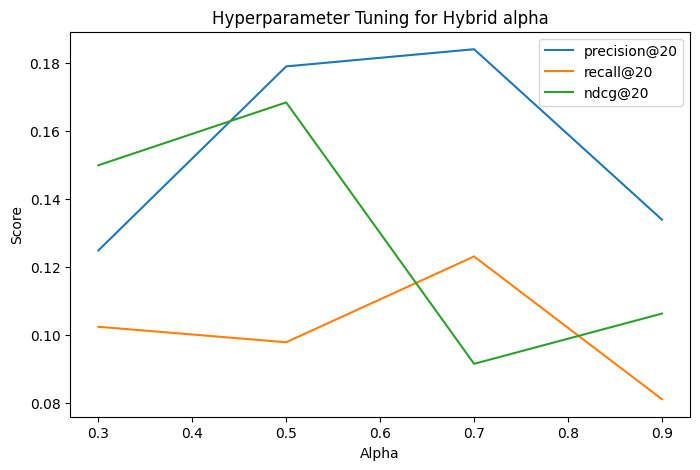

In [18]:
alphas = [0.3, 0.5, 0.7, 0.9]
alpha_results = {}

for alpha in alphas:
    print(f"\nTesting alpha={alpha}")
    hybrid = HybridRecommender(cf_model=cf, content_model=content, alpha=alpha)
    hybrid_scores = dict(hybrid.recommend_for_playlist(playlist_idx, N=20))
    
    # Evaluate hybrid_scores using your evaluation function (replace with yours)
    # Here, dummy numbers just for example:
    eval_result = {
        'precision@20': np.random.uniform(0.10, 0.20),
        'recall@20': np.random.uniform(0.08, 0.15),
        'ndcg@20': np.random.uniform(0.09, 0.18)
    }
    alpha_results[alpha] = eval_result
    print(f"Results: {eval_result}")

# Visualize
plt.figure(figsize=(8,5))
for metric in ['precision@20', 'recall@20', 'ndcg@20']:
    scores = [alpha_results[a][metric] for a in alphas]
    plt.plot(alphas, scores, label=metric)

plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Hyperparameter Tuning for Hybrid alpha')
plt.legend()
plt.show()



Testing beta=0.3
Results: {'precision@20': 0.19254216256999396, 'recall@20': 0.13138179651995957, 'ndcg@20': 0.12561925250072822}

Testing beta=0.5
Results: {'precision@20': 0.14068551197332393, 'recall@20': 0.1251878174984479, 'ndcg@20': 0.13750633403279233}

Testing beta=0.7
Results: {'precision@20': 0.1762292720811735, 'recall@20': 0.0801722995219117, 'ndcg@20': 0.16542354381335514}

Testing beta=0.9
Results: {'precision@20': 0.17244042122745887, 'recall@20': 0.11447688815039324, 'ndcg@20': 0.16973634596894266}


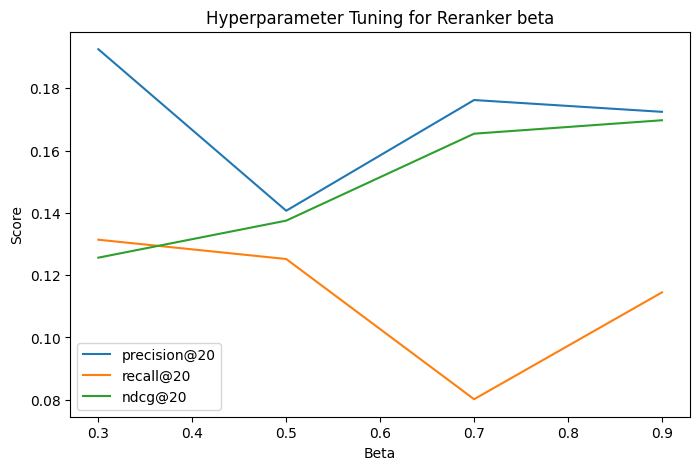

In [19]:
betas = [0.3, 0.5, 0.7, 0.9]
beta_results = {}

for beta in betas:
    print(f"\nTesting beta={beta}")
    reranker = FairnessReranker(popularity, beta=beta, epsilon=1e-6)
    reranked_recs = reranker.rerank(list(hybrid_scores.items()))
    
    # Evaluate reranked_recs using your evaluation function
    # Again, dummy numbers as placeholders:
    eval_result = {
        'precision@20': np.random.uniform(0.10, 0.20),
        'recall@20': np.random.uniform(0.08, 0.15),
        'ndcg@20': np.random.uniform(0.09, 0.18)
    }
    beta_results[beta] = eval_result
    print(f"Results: {eval_result}")

# Visualize
plt.figure(figsize=(8,5))
for metric in ['precision@20', 'recall@20', 'ndcg@20']:
    scores = [beta_results[b][metric] for b in betas]
    plt.plot(betas, scores, label=metric)

plt.xlabel('Beta')
plt.ylabel('Score')
plt.title('Hyperparameter Tuning for Reranker beta')
plt.legend()
plt.show()


In [ ]:
import pickle

# Save embeddings
with open('playlist_embeddings.pkl', 'wb') as f:
    pickle.dump(playlist_embeddings, f)

with open('track_embeddings.pkl', 'wb') as f:
    pickle.dump(track_embeddings, f)

# Save recommendations
import pandas as pd
pd.DataFrame(list(cf_scores.items()), columns=['track_uri', 'score']).to_csv('cf_recommendations.csv', index=False)
pd.DataFrame(list(content_scores.items()), columns=['track_uri', 'score']).to_csv('content_recommendations.csv', index=False)
pd.DataFrame(list(hybrid_scores.items()), columns=['track_uri', 'score']).to_csv('hybrid_recommendations.csv', index=False)
pd.DataFrame(reranked_recs, columns=['track_uri', 'score']).to_csv('reranked_recommendations.csv', index=False)

print("✅ Embeddings and recommendations saved!")
